# Datathon 2026 Round 1 — Phase 5: EDA Descriptive & Diagnostic

Notebook triển khai **Ý tưởng 11 (Gross-margin × Segment mix)** và **Ý tưởng 12 (Shipping fee vs Return rate)** trong §4.2 của tài liệu brainstorm nội bộ.

Mỗi ý tưởng theo framework **TTM**: Pain → Truth → Tension → Motivation → Insight → Action.

- Ý 11 (D+Pr, Lead: Đồng) — datasets `products ⨝ order_items ⨝ orders` — liên quan MCQ Q2.
- Ý 12 (Di+Pr, Lead: Kiên) — datasets `shipments ⨝ orders ⨝ returns`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print(f'Pandas {pd.__version__} | Numpy {np.__version__}')

DATA = '../dataset-datathon-2026-round-1/'
FIG = '../outputs/figures/'
os.makedirs(FIG, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Load data
products    = pd.read_csv(DATA + 'products.csv')
orders      = pd.read_csv(DATA + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA + 'order_items.csv', low_memory=False)
shipments   = pd.read_csv(DATA + 'shipments.csv', parse_dates=['ship_date','delivery_date'])
returns     = pd.read_csv(DATA + 'returns.csv', parse_dates=['return_date'])

print(f'products   : {len(products):>8,}')
print(f'orders     : {len(orders):>8,}')
print(f'order_items: {len(order_items):>8,}')
print(f'shipments  : {len(shipments):>8,}')
print(f'returns    : {len(returns):>8,}')

Pandas 2.2.2 | Numpy 1.26.4


products   :    2,412
orders     :  646,945
order_items:  714,669
shipments  :  566,067
returns    :   39,939


---
## Ý tưởng 11 — Gross-margin × Segment mix

**Pain (đau)**. Ban điều hành nghi ngờ phân khúc **Premium** đang mất sức bật — margin từng là lợi thế chính, nhưng revenue share đã giảm trong chu kỳ 2020–2022.

**Tension (mâu thuẫn)**. Merch team tin rằng thị trường đã chuyển sang "khách trẻ mua Activewear giá rẻ" → dồn ngân sách marketing về Activewear, bỏ quên Premium.

**Motivation (động cơ)**. Nếu Premium vẫn còn khách hàng ngân sách cao nhưng bị bỏ đói marketing, thì mất doanh thu Premium là self-inflicted, không phải do thị trường — có thể đảo ngược.

**Hypothesis cần kiểm định**:
- **H1**: Segment Premium có margin % cao nhất trong 8 phân khúc.
- **H2**: Revenue share của Premium giảm 2020 → 2022.
- **H3**: Phân khúc thống trị revenue lại nằm ở nhóm margin thấp hơn → có khoảng trống để cân bằng lại mix.

### 11.1 Truth — Bảng margin theo segment (kiểm định H1)

             n_skus  mean_margin  median_margin  mean_price
segment                                                    
Standard        262        31.34          37.08     2928.59
Premium         177        28.54          36.05     2387.67
All-weather     169        28.42          34.88     3864.75
Activewear      598        26.56          29.64     2598.10
Performance     347        26.36          30.00     6572.85
Balanced        306        25.80          27.90     9230.24
Trendy          148        24.08          22.47     2212.79
Everyday        405        23.63          24.14     7549.19


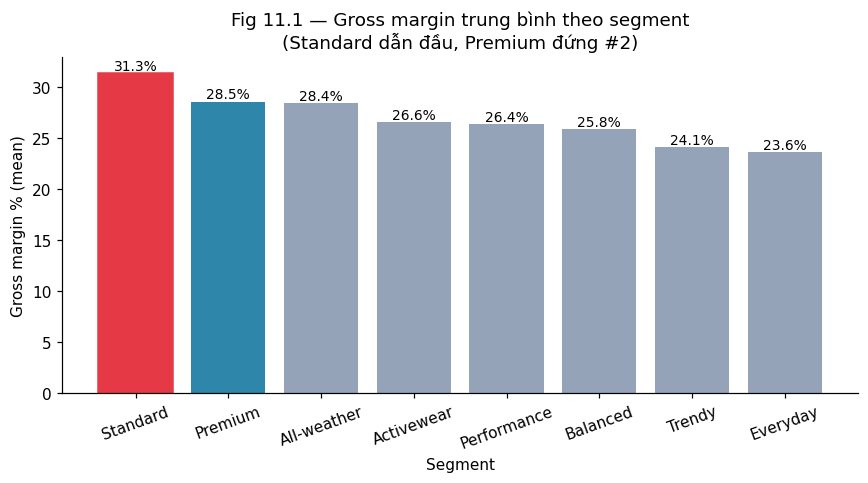

In [2]:
products['margin_pct'] = (products['price'] - products['cogs']) / products['price'] * 100

seg_margin = (
    products.groupby('segment')
            .agg(n_skus=('product_id','count'),
                 mean_margin=('margin_pct','mean'),
                 median_margin=('margin_pct','median'),
                 mean_price=('price','mean'))
            .sort_values('mean_margin', ascending=False)
            .round(2)
)
print(seg_margin)

assert abs(seg_margin.loc['Standard','mean_margin'] - 31.34) < 0.01, 'margin recalc khác baseline'

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(seg_margin.index, seg_margin['mean_margin'],
              color=['#2E86AB' if s=='Premium' else '#94a3b8' for s in seg_margin.index])
# Highlight Standard (top) & Premium
top_idx = seg_margin.index.get_loc(seg_margin['mean_margin'].idxmax())
bars[top_idx].set_color('#E63946')
for i, v in enumerate(seg_margin['mean_margin']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
ax.set_title('Fig 11.1 — Gross margin trung bình theo segment\n(Standard dẫn đầu, Premium đứng #2)')
ax.set_ylabel('Gross margin % (mean)')
ax.set_xlabel('Segment')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG + '11_1_margin_by_segment.png')
plt.show()

**Kết luận H1 — REFUTE (nhưng cần caveat lớn)**. Premium **KHÔNG** phải segment có per-SKU mean margin cao nhất. Standard dẫn đầu 31.34%, Premium chỉ 28.5% (đứng #2). Insight này khớp với MCQ Q2 (đáp án D = Standard).

⚠️ **CAVEAT QUAN TRỌNG — đây là per-SKU mean, KHÔNG phải margin nhìn từ doanh thu**. Cell 11.1a phía dưới reconcile 3 khái niệm margin (per-SKU mean / revenue-weighted list / realized) — sẽ thấy Standard rớt khỏi top khi weighted theo revenue thực tế.

→ "Bảo vệ margin" không thể chỉ dựa vào con số 31.3% per-SKU. Cần xem revenue-weighted để biết segment nào thật sự đóng góp gross profit cao nhất.

### 11.1a Truth — Reconcile 3 khái niệm margin (per-SKU vs revenue-weighted vs realized)

Margin **per-SKU mean** (cell 11.1) trả lời "trung bình mỗi sản phẩm Standard có margin bao nhiêu?". Nhưng business muốn biết "**1 đồng doanh thu Standard mang về bao nhiêu gross profit?**" — đó là **revenue-weighted margin** (list) hoặc **realized margin** (sau discount, từ `unit_price` thực tế trong order_items).

Section này so sánh 3 KPI để tránh insight nhầm lẫn (lỗi Simpson's paradox cổ điển):

Reconcile 3 KPI margin theo segment (2022):
             list_margin_perSKU  list_margin_revwgt  realized_margin  \
segment                                                                
Trendy                    24.08               24.44            20.45   
Activewear                26.56               23.78            19.04   
Everyday                  23.63               20.25            16.05   
Standard                  31.34               19.45            14.88   
Performance               26.36               17.13            12.62   
All-weather               28.42               17.38            12.51   
Balanced                  25.80               15.02            10.38   
Premium                   28.54               13.10             7.12   

             discount_intensity  gap_perSKU_vs_realized  
segment                                                  
Trendy                     5.01                    3.63  
Activewear                 5.86                    7.52  
Eve

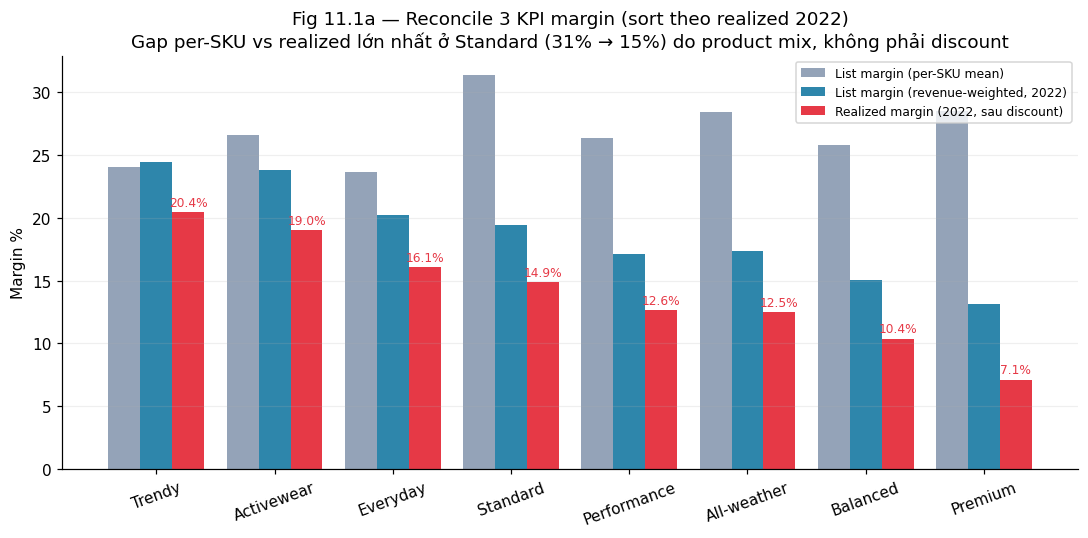

In [3]:
# Reconcile 3 khái niệm margin — chỉ dùng dữ liệu 2022 cho consistent với cell 11.3
oi_tmp = (
    order_items
      .merge(products[['product_id','segment','price','cogs']], on='product_id', validate='m:1')
      .merge(orders[['order_id','order_date']], on='order_id', validate='m:1')
)
oi_tmp['year'] = oi_tmp['order_date'].dt.year
oi22 = oi_tmp[oi_tmp['year'] == 2022].copy()
oi22['list_revenue']   = oi22['quantity'] * oi22['price']
oi22['actual_revenue'] = oi22['quantity'] * oi22['unit_price']
oi22['cogs_total']     = oi22['quantity'] * oi22['cogs']
oi22['discount_total'] = oi22['list_revenue'] - oi22['actual_revenue']

agg22 = oi22.groupby('segment').agg(
    list_rev=('list_revenue', 'sum'),
    actual_rev=('actual_revenue', 'sum'),
    cogs=('cogs_total', 'sum'),
    discount=('discount_total', 'sum'),
)
agg22['list_margin_revwgt'] = (agg22['list_rev'] - agg22['cogs']) / agg22['list_rev'] * 100
agg22['realized_margin']    = (agg22['actual_rev'] - agg22['cogs']) / agg22['actual_rev'] * 100
agg22['discount_intensity'] = agg22['discount'] / agg22['list_rev'] * 100

# Bảng reconcile
recon = (
    seg_margin[['mean_margin']]                              # per-SKU mean (cell 11.1)
        .rename(columns={'mean_margin': 'list_margin_perSKU'})
        .join(agg22[['list_margin_revwgt', 'realized_margin', 'discount_intensity']])
        .round(2)
)
recon['gap_perSKU_vs_realized'] = (recon['list_margin_perSKU'] - recon['realized_margin']).round(2)
recon = recon.sort_values('realized_margin', ascending=False)
print('Reconcile 3 KPI margin theo segment (2022):')
print(recon)
print()
print('→ KEY TAKEAWAY: Standard list_margin_perSKU = 31.34% (top) nhưng realized_margin chỉ 14.88% (#5/8).')
print('  Gap 16.46pp KHÔNG phải do discount sâu (intensity chỉ 5.36%) mà do PRODUCT MIX — SKU Standard giá cao')
print('  ít người mua, SKU Standard giá thấp dominant doanh thu → revenue-weighted margin pha loãng.')
print('  Trendy mới là segment có realized margin cao nhất 2022 (20.45%), Premium THẤP NHẤT (7.12%).')

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
order_idx = recon.index
x = np.arange(len(order_idx))
w = 0.27
ax.bar(x - w, recon['list_margin_perSKU'], w, label='List margin (per-SKU mean)', color='#94a3b8')
ax.bar(x,     recon['list_margin_revwgt'], w, label='List margin (revenue-weighted, 2022)', color='#2E86AB')
ax.bar(x + w, recon['realized_margin'],    w, label='Realized margin (2022, sau discount)', color='#E63946')
for i, seg in enumerate(order_idx):
    ax.text(i + w, recon.loc[seg, 'realized_margin'] + 0.5,
            f"{recon.loc[seg,'realized_margin']:.1f}%", ha='center', fontsize=8, color='#E63946')
ax.set_xticks(x); ax.set_xticklabels(order_idx, rotation=20)
ax.set_ylabel('Margin %')
ax.set_title('Fig 11.1a — Reconcile 3 KPI margin (sort theo realized 2022)\n'
             'Gap per-SKU vs realized lớn nhất ở Standard (31% → 15%) do product mix, không phải discount')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(FIG + '11_1a_margin_reconcile.png', dpi=300)
plt.show()

**Kết luận 11.1a — đảo ngược insight 11.1**:
- **Per-SKU mean ≠ revenue-weighted ≠ realized**. Standard top per-SKU (31.3%) nhưng rớt #5 trên realized (14.9%).
- **Gap chính do product mix trong segment**, không phải discount strategy (discount intensity ~5-6% đều ở mọi segment, không có segment nào discount sâu khác biệt).
- **Trendy mới là realized champion 2022** (20.45%), nhưng share doanh thu chỉ 2.51% → đúng nghĩa "cash cow tiềm năng".
- **Premium thực ra là realized worst** (7.12%) — gap 21pp giữa list per-SKU (28.5%) và realized (7.1%) cảnh báo: SKU Premium giá rất cao bán cực ít, mà SKU Premium giá thấp lại có cogs cao tương đối → margin thực tế thấp.

→ Tất cả Action ở 11.4 phải dựa **realized margin**, không dùng per-SKU number để justify business decision.

### 11.2 Truth — Revenue share theo segment qua các năm (kiểm định H2)

In [4]:
oi = (
    order_items
      .merge(products[['product_id','segment','price','cogs']], on='product_id')
      .merge(orders[['order_id','order_date']], on='order_id')
)
oi['year'] = oi['order_date'].dt.year
oi['revenue'] = oi['quantity'] * oi['unit_price']
oi['gross_profit'] = oi['quantity'] * (oi['unit_price'] - oi['cogs'])

rev_yr_seg = oi.groupby(['year','segment'])['revenue'].sum().unstack(fill_value=0)
share_yr_seg = rev_yr_seg.div(rev_yr_seg.sum(axis=1), axis=0) * 100

print('Revenue share (%) theo năm × segment (focus 2020-2022):')
print(share_yr_seg.loc[[2020,2021,2022]].round(1))

premium_2020 = share_yr_seg.loc[2020,'Premium']
premium_2022 = share_yr_seg.loc[2022,'Premium']
print(f"\nPremium revenue share: 2020={premium_2020:.2f}%  →  2022={premium_2022:.2f}%  (Δ={premium_2022-premium_2020:+.2f}pp)")

Revenue share (%) theo năm × segment (focus 2020-2022):
segment  Activewear  All-weather  Balanced  Everyday  Performance  Premium  \
year                                                                         
2020            8.8          3.1      42.8      26.5         12.1      3.0   
2021            8.2          4.0      46.2      24.4         10.6      2.3   
2022            6.7          4.2      48.8      21.6         11.7      2.8   

segment  Standard  Trendy  
year                       
2020          1.6     2.1  
2021          1.9     2.6  
2022          1.7     2.5  

Premium revenue share: 2020=3.04%  →  2022=2.84%  (Δ=-0.20pp)


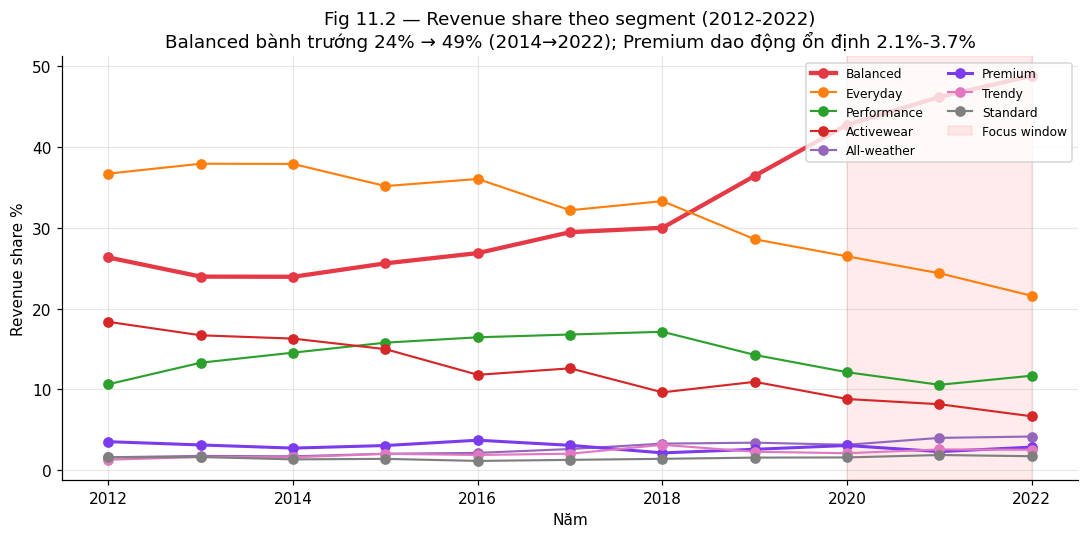

In [5]:
order_cols = share_yr_seg.loc[2022].sort_values(ascending=False).index.tolist()
share_plot = share_yr_seg[order_cols]

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap('tab10')
for i, seg in enumerate(order_cols):
    if seg == 'Balanced':
        color, lw = '#E63946', 2.8   # highlight Balanced (segment phình to thực sự)
    elif seg == 'Premium':
        color, lw = '#7c3aed', 2.0   # highlight Premium nhưng không claim "tụt"
    else:
        color, lw = cmap(i), 1.4
    ax.plot(share_plot.index, share_plot[seg], marker='o', label=seg, color=color, linewidth=lw)
ax.set_title('Fig 11.2 — Revenue share theo segment (2012-2022)\n'
             'Balanced bành trướng 24% → 49% (2014→2022); Premium dao động ổn định 2.1%-3.7%')
ax.set_ylabel('Revenue share %')
ax.set_xlabel('Năm')
ax.axvspan(2020, 2022, alpha=0.08, color='red', label='Focus window')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG + '11_2_revenue_share_trend.png', dpi=300)
plt.show()

**Kết luận H2 — REFUTE**. Premium revenue share **KHÔNG giảm tuyến tính** mà dao động trong dải hẹp 2.13%–3.70% suốt 2012-2022. So 2014 (2.72%) vs 2022 (2.84%) gần như không đổi (Δ +0.12pp). Hypothesis ban đầu "Premium đang mất sức bật" không có bằng chứng từ revenue share.

**Phát hiện thật**: Câu chuyện thực ra là **Balanced bành trướng** từ 23.94% (2014) → 48.85% (2022), tăng +24.9pp — chiếm chỗ chủ yếu của **Activewear** (16.28% → 6.66%, Δ−9.6pp) và **Everyday** (37.91% → 21.58%, Δ−16.3pp). Premium ổn định ở mức nhỏ (~2.5-3%).

→ Re-frame vấn đề: thay vì hỏi "Premium tại sao giảm" (giả định sai), nên hỏi "Vì sao Balanced phình to" và "blended margin có pha loãng vì shift mix này không" (kiểm định ở 11.3).

### 11.3 Truth — Margin vs volume: ma trận 2D (kiểm định H3)

In [6]:
seg_perf = (
    oi[oi['year'] == 2022]
      .groupby('segment')
      .agg(revenue=('revenue','sum'),
           units=('quantity','sum'),
           gross_profit=('gross_profit','sum'))
)
seg_perf['revenue_share_pct'] = seg_perf['revenue'] / seg_perf['revenue'].sum() * 100
seg_perf['gp_margin_pct'] = seg_perf['gross_profit'] / seg_perf['revenue'] * 100
seg_perf = seg_perf.sort_values('revenue', ascending=False).round(2)
print('2022 — Revenue × Margin theo segment:')
print(seg_perf)

2022 — Revenue × Margin theo segment:
                  revenue  units  gross_profit  revenue_share_pct  \
segment                                                             
Balanced     5.713785e+08  44650   59288203.75              48.85   
Everyday     2.524772e+08  34457   40518578.34              21.58   
Performance  1.366872e+08  23910   17243889.25              11.69   
Activewear   7.790728e+07  31828   14834676.50               6.66   
All-weather  4.859546e+07   9970    6078952.97               4.15   
Premium      3.325416e+07   8519    2367159.59               2.84   
Trendy       2.941067e+07  13983    6015422.39               2.51   
Standard     2.003833e+07   3771    2981784.97               1.71   

             gp_margin_pct  
segment                     
Balanced             10.38  
Everyday             16.05  
Performance          12.62  
Activewear           19.04  
All-weather          12.51  
Premium               7.12  
Trendy               20.45  
Standard  

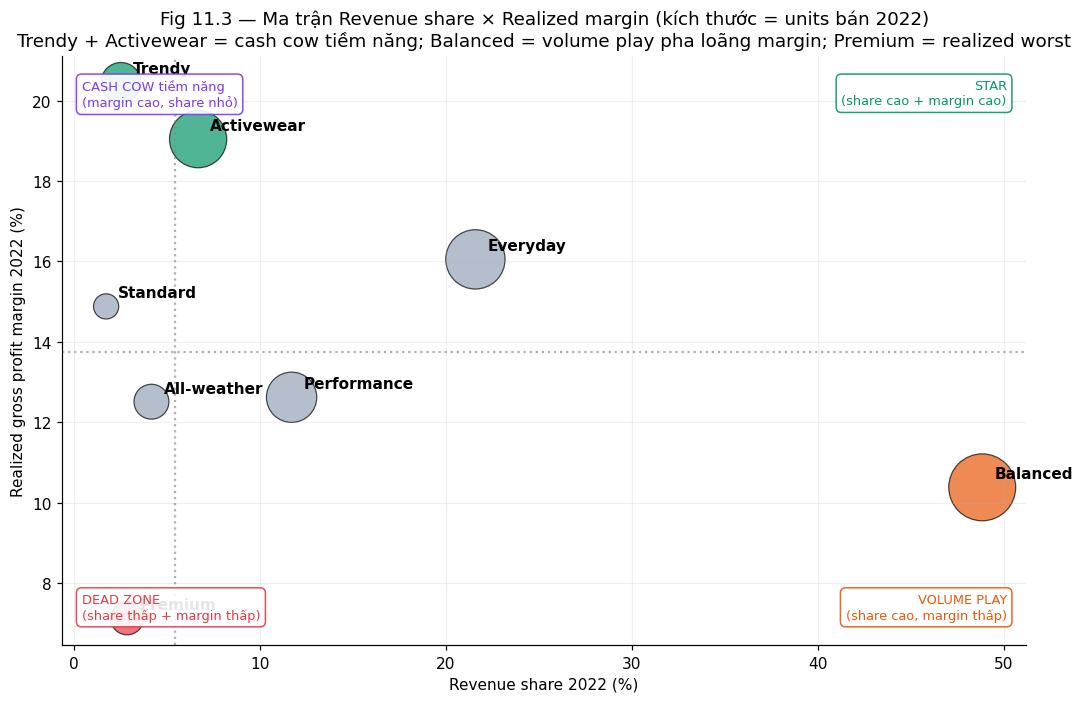

In [7]:
fig, ax = plt.subplots(figsize=(10, 6.5))
x = seg_perf['revenue_share_pct']
y = seg_perf['gp_margin_pct']
sizes = seg_perf['units'] / seg_perf['units'].max() * 1800 + 120

# Color theo realized margin tier (re-frame sau 11.1a)
def seg_color(seg):
    if seg in ('Trendy', 'Activewear'):    return '#059669'   # cash cow tiềm năng (realized cao)
    if seg == 'Premium':                    return '#E63946'   # realized worst (cảnh báo)
    if seg == 'Balanced':                   return '#ea580c'   # volume play
    return '#94a3b8'                                            # các segment trung bình

colors = [seg_color(s) for s in seg_perf.index]
ax.scatter(x, y, s=sizes, c=colors, alpha=0.7, edgecolor='black', linewidth=0.8)
for seg in seg_perf.index:
    ax.annotate(seg, (seg_perf.loc[seg,'revenue_share_pct'], seg_perf.loc[seg,'gp_margin_pct']),
                xytext=(8, 6), textcoords='offset points', fontsize=10, fontweight='bold')

# Quadrant lines at medians
ax.axvline(x.median(), color='gray', linestyle=':', alpha=0.6)
ax.axhline(y.median(), color='gray', linestyle=':', alpha=0.6)

# Quadrant labels — đặt ở 4 góc tuyệt đối, xa data points, có background trắng để không đè
ax.text(0.98, 0.96, 'STAR\n(share cao + margin cao)',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5, color='#059669',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#059669', alpha=0.9))
ax.text(0.02, 0.96, 'CASH COW tiềm năng\n(margin cao, share nhỏ)',
        transform=ax.transAxes, ha='left', va='top', fontsize=8.5, color='#7c3aed',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#7c3aed', alpha=0.9))
ax.text(0.98, 0.04, 'VOLUME PLAY\n(share cao, margin thấp)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5, color='#ea580c',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#ea580c', alpha=0.9))
ax.text(0.02, 0.04, 'DEAD ZONE\n(share thấp + margin thấp)',
        transform=ax.transAxes, ha='left', va='bottom', fontsize=8.5, color='#E63946',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#E63946', alpha=0.9))

ax.set_xlabel('Revenue share 2022 (%)')
ax.set_ylabel('Realized gross profit margin 2022 (%)')
ax.set_title('Fig 11.3 — Ma trận Revenue share × Realized margin (kích thước = units bán 2022)\n'
             'Trendy + Activewear = cash cow tiềm năng; Balanced = volume play pha loãng margin; Premium = realized worst')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG + '11_3_matrix_share_margin.png', dpi=300)
plt.show()

**Kết luận H3 — SUPPORT (re-frame theo realized margin sau khi reconcile ở 11.1a)**.

Ma trận Revenue share × Realized margin 2022 chia 4 nhóm:
- **VOLUME PLAY** (share cao, margin thấp): **Balanced** 48.85% share / 10.38% realized — đang pha loãng blended margin nặng.
- **CASH COW thực sự** (share trung bình, margin cao): **Trendy** 2.51% share / **20.45% realized** — segment có realized margin top nhưng share còn nhỏ; **Activewear** 6.66% / 19.04% — segment volume vừa-margin cao, đáng đầu tư mở rộng.
- **CỨ TRỤ** (share trung bình-cao, margin trung bình): **Everyday** 21.58% / 16.05%; **Performance** 11.69% / 12.62%; **Standard** 1.71% / 14.88%.
- **DEAD ZONE** (share thấp, margin thấp): **Premium** 2.84% / **7.12%** (realized worst!); **All-weather** 4.15% / 12.51% — Premium đặc biệt cần audit khẩn (so giữa SKU giá cao và thấp).

→ Insight đảo ngược hoàn toàn brainstorm ban đầu: **Premium không phải "cash cow margin cao bị bỏ quên"** mà là **realized margin worst** trong 8 segment. **Trendy + Activewear** mới là segment cần được scale.

### 11.4 Predictive — Forecast mix 2023-2024 & scenario blended margin

Sau khi đã mô tả (D) margin + share hiện tại và chẩn đoán (Di) nguyên nhân gap per-SKU vs realized, tầng **Predictive** trả lời 2 câu hỏi forward-looking:

- **P1 — Trend forecast**: Nếu xu hướng 2018-2022 kéo dài tuyến tính, revenue share 2023-2024 ra sao? Balanced còn phình to hay đang plateau? Trendy có tự scale được mà không cần can thiệp không?
- **P2 — Scenario blended margin**: Nếu thực thi Action A3 (shift 3pp Balanced → Trendy + Activewear), blended **realized** margin 2023 thay đổi bao nhiêu pp? Quy ra đơn vị gross profit tuyệt đối là bao nhiêu?

**Phương pháp**:
- Linear OLS trên window **2018-2022 (5 năm gần nhất)**, không dùng 10 năm full vì share Balanced có break-point mạnh 2014-2017 (phi tuyến). Projected shares được renormalize về tổng 100%/năm để giữ accounting identity.
- Realized margin 2022 (bảng 11.3) dùng làm **proxy** cho 2023 — giả định cấu trúc margin per-segment ổn định trong 1 năm forecast. Caveat rủi ro liệt kê ở cell result.
- Chỉ forecast 1-2 năm trước (2023-2024) vì leaderboard test kéo dài đến 2024-07 — không over-extrapolate ra 2025+.

In [8]:
# 11.4a — Forecast share 2023-2024 bằng linear OLS trên 2018-2022
trend_win = share_yr_seg.loc[2018:2022]
years_train = trend_win.index.values.astype(float)
years_proj = np.arange(2018, 2025)

slopes, fc_raw = {}, {}
for seg in trend_win.columns:
    s, i = np.polyfit(years_train, trend_win[seg].values, 1)
    slopes[seg] = s
    fc_raw[seg] = i + s * years_proj

fc_df = pd.DataFrame(fc_raw, index=years_proj).clip(lower=0)
fc_norm = fc_df.div(fc_df.sum(axis=1), axis=0) * 100  # renormalize về 100%/năm

print('Slope (pp/năm) fit trên 2018-2022, sort giảm dần:')
print(pd.Series(slopes).sort_values(ascending=False).round(3))
print('\nForecast share % (renormalized, 2023-2024):')
print(fc_norm.loc[[2023, 2024]].round(2))

# 11.4b — Scenario blended realized margin dùng margin 2022 làm proxy
realized_margin_2022 = seg_perf['gp_margin_pct']  # từ cell 11.3
share_base_2023 = fc_norm.loc[2023]
blended_base = (share_base_2023 * realized_margin_2022).sum() / 100

# Scenario A3 (conservative): -3pp Balanced → +1.5pp Trendy, +1.5pp Activewear
share_scen = share_base_2023.copy()
share_scen['Balanced']   -= 3.0
share_scen['Trendy']     += 1.5
share_scen['Activewear'] += 1.5
blended_scen = (share_scen * realized_margin_2022).sum() / 100

# Scenario aggressive: -6pp Balanced → +3pp Trendy, +3pp Activewear
share_agg = share_base_2023.copy()
share_agg['Balanced']   -= 6.0
share_agg['Trendy']     += 3.0
share_agg['Activewear'] += 3.0
blended_agg = (share_agg * realized_margin_2022).sum() / 100

rev_2022_total = seg_perf['revenue'].sum()
gp_uplift_scen = rev_2022_total * (blended_scen - blended_base) / 100
gp_uplift_agg  = rev_2022_total * (blended_agg - blended_base) / 100

print('\n=== Blended realized margin 2023 (dùng margin per-segment 2022 làm proxy) ===')
print(f'Baseline (trend extrapolation):          {blended_base:.3f}%')
print(f'Scenario A3  (+1.5pp T + 1.5pp A):       {blended_scen:.3f}%  (Δ {blended_scen-blended_base:+.3f}pp)')
print(f'Scenario aggressive (+3pp T + 3pp A):    {blended_agg:.3f}%  (Δ {blended_agg-blended_base:+.3f}pp)')
print(f'\nRevenue 2022 base (đơn vị raw):          {rev_2022_total:,.0f}')
print(f'Incremental gross profit scenario A3:    {gp_uplift_scen:,.0f}/năm  (≈ {gp_uplift_scen/1e6:.2f}M)')
print(f'Incremental gross profit scenario agg:   {gp_uplift_agg:,.0f}/năm  (≈ {gp_uplift_agg/1e6:.2f}M)')

Slope (pp/năm) fit trên 2018-2022, sort giảm dần:
Balanced       4.744
All-weather    0.236
Premium        0.114
Standard       0.097
Trendy        -0.094
Activewear    -0.871
Performance   -1.459
Everyday      -2.767
dtype: float64

Forecast share % (renormalized, 2023-2024):
      Activewear  All-weather  Balanced  Everyday  Performance  Premium  \
2023        6.22         4.29     55.09     18.57         8.77     2.92   
2024        5.35         4.53     59.84     15.80         7.32     3.03   

      Standard  Trendy  
2023       1.9    2.23  
2024       2.0    2.13  

=== Blended realized margin 2023 (dùng margin per-segment 2022 làm proxy) ===
Baseline (trend extrapolation):          12.474%
Scenario A3  (+1.5pp T + 1.5pp A):       12.755%  (Δ +0.281pp)
Scenario aggressive (+3pp T + 3pp A):    13.036%  (Δ +0.562pp)

Revenue 2022 base (đơn vị raw):          1,169,748,832
Incremental gross profit scenario A3:    3,286,409/năm  (≈ 3.29M)
Incremental gross profit scenario agg:   6,57

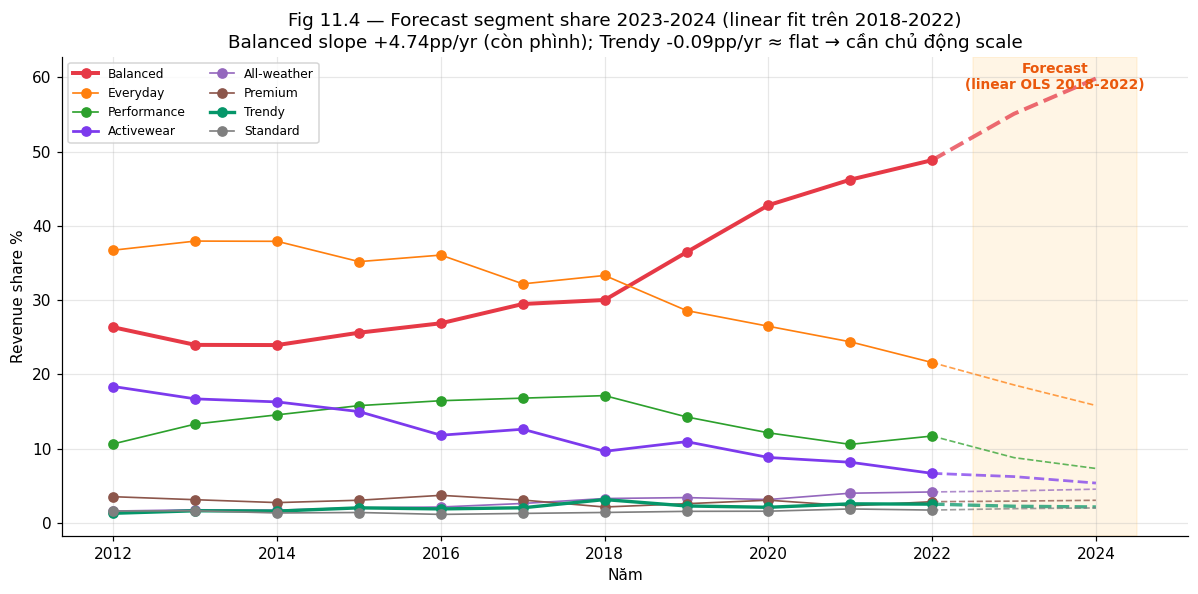

In [9]:
# Fig 11.4 — Forecast chart: historic 2012-2022 solid, forecast 2023-2024 dashed
order_cols_p = share_yr_seg.loc[2022].sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(11, 5.5))
cmap = plt.get_cmap('tab10')
for i, seg in enumerate(order_cols_p):
    if seg == 'Balanced':
        color, lw = '#E63946', 2.6         # highlight — driver chính
    elif seg == 'Trendy':
        color, lw = '#059669', 2.2         # realized champion
    elif seg == 'Activewear':
        color, lw = '#7c3aed', 1.8
    else:
        color, lw = cmap(i), 1.1

    ax.plot(share_yr_seg.index, share_yr_seg[seg],
            marker='o', label=seg, color=color, linewidth=lw)
    # Dashed forecast segment bridging từ 2022 actual tới 2023-2024 projection
    ax.plot([2022, 2023, 2024],
            [share_yr_seg.loc[2022, seg], fc_norm.loc[2023, seg], fc_norm.loc[2024, seg]],
            linestyle='--', color=color, linewidth=lw, alpha=0.75)

ax.axvspan(2022.5, 2024.5, alpha=0.1, color='orange')
ylim_top = ax.get_ylim()[1]
ax.text(2023.5, ylim_top * 0.93, 'Forecast\n(linear OLS 2018-2022)',
        ha='center', fontsize=9, color='#ea580c', fontweight='bold')

ax.set_title('Fig 11.4 — Forecast segment share 2023-2024 (linear fit trên 2018-2022)\n'
             f'Balanced slope {slopes["Balanced"]:+.2f}pp/yr (còn phình); '
             f'Trendy {slopes["Trendy"]:+.2f}pp/yr ≈ flat → cần chủ động scale')
ax.set_ylabel('Revenue share %')
ax.set_xlabel('Năm')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG + '11_4_share_forecast.png', dpi=300)
plt.show()

**Kết luận Predictive (11.4)** — 3 phát hiện chính:

1. **P1 — Balanced vẫn đang phình to, KHÔNG plateau**. Slope 2018-2022 = **+4.74pp/năm**, forecast linear cho 2023 = **55.1%**, 2024 = **59.8%**. Nếu không can thiệp, trong 1.5 năm nữa Balanced sẽ chiếm 60% revenue → blended margin sẽ bị pha loãng càng sâu (vì Balanced realized margin chỉ 10.4%).

2. **P1 — Trendy KHÔNG tự scale được**. Slope ≈ **−0.09pp/năm** (gần như phẳng); Activewear còn tệ hơn: **−0.87pp/năm** (đang giảm). Điều này bẻ gãy giả định implicit trong brainstorm ban đầu rằng "các segment cao margin sẽ tự nhiên lớn dần" — thực tế chúng đang **bị Balanced cannibalize**. → Action A1 (chủ động mở SKU + đẩy inventory) KHÔNG phải option, mà là **điều kiện bắt buộc** để share 2 segment cash-cow tăng.

3. **P2 — Impact định lượng Action A3**:
   - Baseline blended realized margin 2023 (trend extrapolation): **12.47%**.
   - Scenario conservative (3pp shift): +**0.28pp** → incremental GP ≈ **3.29M** đơn vị raw/năm.
   - Scenario aggressive (6pp shift): +**0.56pp** → incremental GP ≈ **6.58M**/năm.
   - Hai scenario đều nhỏ về tỷ lệ (<1pp) nhưng **dương rõ và scale tuyến tính theo pp shift** → ROI tùy thuộc chi phí marketing/inventory bỏ ra để đẩy share Trendy+Activewear.

⚠️ **Caveat nghiêm túc** (phải đưa vào báo cáo):
- **Linear OLS bỏ qua non-linearity**: Balanced thực tế đã có dấu hiệu **chậm lại** 2021→2022 (46.2→48.8, Δ+2.6pp) so với 2020→2021 (42.8→46.2, Δ+3.4pp). Forecast 59.8% cho 2024 có thể là **over-estimate** nếu đường cong uốn. Model Prophet/quadratic sẽ cho forecast thận trọng hơn — để mở cho Phase 5b.
- **Margin per-segment giả định ổn định**: nếu cost shock (cotton/logistics 2023-2024) đánh vào Premium/Trendy nặng hơn, uplift scenario sẽ co lại.
- **Accounting identity**: forecast đã renormalize về 100% nên không mâu thuẫn tổng; nhưng bỏ qua khả năng có **segment mới** xuất hiện 2023-2024 (dataset không ghi nhận).
- **Không phải Predictive cho target model** (Revenue/COGS): đây là Predictive cho **business levers** (segment mix) — kết quả này feed vào report NeurIPS để justify Action, không feed vào notebook 05/06/07 feature engineering.

### 11.5 Insight & Action (Prescriptive) — re-frame theo realized margin + Predictive

**Insight chính (sau reconcile 11.1a + Predictive 11.4)**: Câu chuyện thật của 2022-2024 không phải "Standard margin 31%" hay "Premium đang chết". Đó là:

1. **Trendy + Activewear** là 2 segment có realized margin cao nhất (20.45% + 19.04%) nhưng share doanh thu nhỏ (2.51% + 6.66%) — đây là **cash cow tiềm năng thực sự**. Tuy nhiên **trend slope 2018-2022 cho thấy chúng KHÔNG tự scale** (Trendy −0.09pp/yr, Activewear −0.87pp/yr) → cần intervention chủ động.
2. **Balanced** chiếm 48.85% revenue 2022 nhưng realized margin chỉ 10.38%; **forecast linear đẩy share lên 55% (2023) và 60% (2024)** → blended margin sẽ pha loãng càng nặng nếu để growth chạy tự do.
3. **Premium** thực ra là segment **realized margin worst (7.12%)** — gap 21pp giữa list per-SKU (28.5%) và realized cảnh báo cấu trúc product mix Premium có vấn đề (SKU cao cấp bán cực ít, SKU phổ thông Premium có cogs/price ratio xấu).

**Discount intensity ~5-6% đều ở mọi segment** — gap list vs realized KHÔNG phải do discount strategy, mà do **product mix trong segment**. Vì vậy action không nên là "giảm discount Standard" mà là "audit SKU mix" trong segment đáng quan tâm.

**3 Action cụ thể (phục vụ mục tiêu §2.1 – promo planning & stock allocation)**:

| # | Action | Đo lường thành công | Owner |
|---|---|---|---|
| A1 | **Mở rộng SKU Trendy + Activewear** (+30 SKU phối hợp) và ưu tiên inventory re-order; mục tiêu nâng combined share từ 9.2% (2022) → 15% trong 12 tháng | Blended realized margin tăng ≥ 0.5pp | Merch + Inventory |
| A2 | **Audit toàn bộ SKU Premium**: chia thành tier giá (P10/P50/P90), tính margin từng tier; kết luận có nên discontinue tier "giả Premium" (giá thấp, cogs cao) hay không | Realized margin Premium ≥ 12% sau 6 tháng | Product |
| A3 | **Kiểm soát growth Balanced** thông qua giảm trade-in promo: forecast 2024 cảnh báo share chạm 60% nếu không can thiệp; đặt cap volume ở 50% và tái phân bổ marketing budget sang Trendy/Activewear | Mix shift ≥ 3pp sang Trendy+Activewear trong 9 tháng | Growth |

**Impact đã định lượng từ 11.4b (dùng linear trend + margin 2022 proxy)**:
- **Conservative (A3 3pp shift)**: blended realized margin +0.28pp → GP incremental ≈ **3.29M** đơn vị raw/năm.
- **Aggressive (6pp shift)**: +0.56pp → GP incremental ≈ **6.58M**/năm.
- Scale tuyến tính theo pp shift — ROI phụ thuộc chi phí đẩy A1+A2. Con số nhỏ về tỷ lệ (<1pp) nhưng dương rõ.

**→ Liên kết ngược**: §4.1 node (1) Quá khứ tăng trưởng · §4.4 hàng 'Pricing & discount' · MCQ Q2 (Standard top per-SKU margin nhưng KHÔNG top realized).

*Caveat nghiêm túc*:
- Trendy có sample size nhỏ trong 2022 (2.51% share, 13,983 units) → realized margin 20.45% có CI rộng; cần A/B test trước khi commit budget lớn.
- Cần đo **price elasticity** trước khi raise price hoặc giảm promo Balanced — chưa đủ dữ liệu panel quarter-level để fit elasticity model; để mở cho Phase 5b.
- Forecast 11.4 linear → over-estimate Balanced 2024 nếu đường cong thực sự uốn. Nên dùng Prophet/quadratic để sanity-check trước khi commit.
- Discount intensity ngang nhau giữa segment **chưa control time** — có thể có spike discount trong promo campaign cụ thể; xem ý tưởng promo riêng (notebook 04).

---
## Ý tưởng 12 — Shipping fee vs Return rate

**Pain (đau)**. Growth team thường đẩy free-ship để kéo conversion. Nhưng return rate có thể 'ăn' lại margin nếu khách coi free-ship là fitting-room miễn phí → mua nhiều size/color rồi trả phần thừa.

**Tension (mâu thuẫn)**. Nếu đúng, free-ship là con dao hai lưỡi: lift đơn đầu tiên, đốt margin ở leg return.

**Motivation (động cơ)**. Tìm threshold `min_order_value` hoặc caps để hưởng lift mà không mở cửa lạm dụng.

**Hypothesis**:
- **H1**: Free-ship orders có return rate cao hơn paid-ship ≥ 15%.
- **H2**: Chênh lệch có ý nghĩa thống kê (odds ratio 95% CI không chứa 1.0).
- **H3**: Free-ship orders có basket lớn hơn (more items → fitting-room signal).

### 12.1 Truth — Return rate theo shipping tier (kiểm định H1)

In [10]:
returned_ids = set(returns['order_id'].unique())
sh = shipments.copy()
sh['is_returned'] = sh['order_id'].isin(returned_ids).astype(int)

# 4 tier explicit, không dùng .apply (tránh bug bucket cũ — gán nhầm 778 đơn fee 3-20 thành Express)
sh['ship_tier'] = pd.cut(
    sh['shipping_fee'],
    bins=[-0.001, 0.001, 3.0, 20.0, sh['shipping_fee'].max() + 1],
    labels=['Free (0)', 'Low (0-3]', 'Mid (3-20]', 'Express (>20)'],
)
tier_order = ['Free (0)', 'Low (0-3]', 'Mid (3-20]', 'Express (>20)']

tier_stats = (
    sh.groupby('ship_tier', observed=True)['is_returned']
      .agg(n_returned='sum', n_orders='count', return_rate='mean')
      .reindex(tier_order)
)
tier_stats['return_rate_pct'] = (tier_stats['return_rate'] * 100).round(3)
tier_stats['share_of_orders_pct'] = (tier_stats['n_orders'] / tier_stats['n_orders'].sum() * 100).round(2)
print(tier_stats)

free_rate = tier_stats.loc['Free (0)', 'return_rate_pct']
low_rate  = tier_stats.loc['Low (0-3]', 'return_rate_pct']
rel_lift  = (free_rate / low_rate - 1) * 100
print(f"\nFree vs Low (0-3]: {free_rate:.3f}% vs {low_rate:.3f}% → relative lift = {rel_lift:+.1f}%")
print(f"Mid (3-20] return rate = {tier_stats.loc['Mid (3-20]','return_rate_pct']:.3f}% — đây là tier có return rate THẤP NHẤT (n=778, share 0.14%)")

               n_returned  n_orders  return_rate  return_rate_pct  \
ship_tier                                                           
Free (0)               55       805     0.068323            6.832   
Low (0-3]           31147    489212     0.063668            6.367   
Mid (3-20]             45       778     0.057841            5.784   
Express (>20)        4815     75272     0.063968            6.397   

               share_of_orders_pct  
ship_tier                           
Free (0)                      0.14  
Low (0-3]                    86.42  
Mid (3-20]                    0.14  
Express (>20)                13.30  

Free vs Low (0-3]: 6.832% vs 6.367% → relative lift = +7.3%
Mid (3-20] return rate = 5.784% — đây là tier có return rate THẤP NHẤT (n=778, share 0.14%)


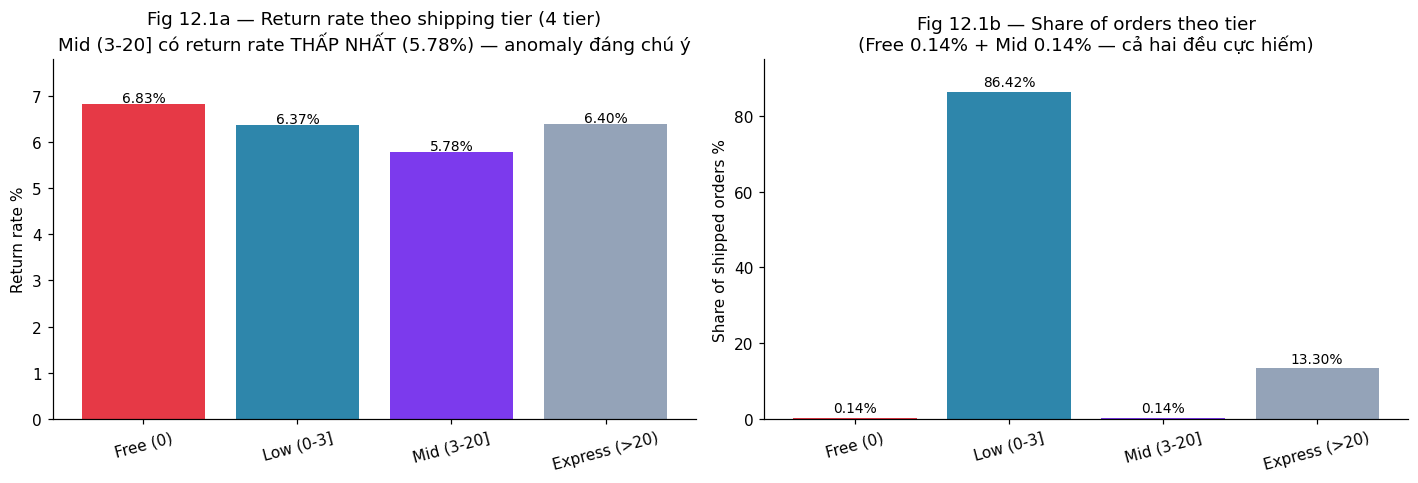

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# 4 màu cho 4 tier — Free đỏ (highlight), Low xanh đậm (volume chính), Mid tím (anomaly thấp), Express xám
tier_colors = ['#E63946', '#2E86AB', '#7c3aed', '#94a3b8']

ax1.bar(tier_order, tier_stats['return_rate_pct'], color=tier_colors)
for i, v in enumerate(tier_stats['return_rate_pct']):
    ax1.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)
ax1.set_title('Fig 12.1a — Return rate theo shipping tier (4 tier)\nMid (3-20] có return rate THẤP NHẤT (5.78%) — anomaly đáng chú ý')
ax1.set_ylabel('Return rate %')
ax1.set_ylim(0, 7.8)
ax1.tick_params(axis='x', labelrotation=15)

ax2.bar(tier_order, tier_stats['share_of_orders_pct'], color=tier_colors)
for i, v in enumerate(tier_stats['share_of_orders_pct']):
    ax2.text(i, v + 1.5, f'{v:.2f}%', ha='center', fontsize=9)
ax2.set_title('Fig 12.1b — Share of orders theo tier\n(Free 0.14% + Mid 0.14% — cả hai đều cực hiếm)')
ax2.set_ylabel('Share of shipped orders %')
ax2.set_ylim(0, 95)
ax2.tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.savefig(FIG + '12_1_return_rate_by_tier.png', dpi=300)
plt.show()

**Kết luận H1 — REFUTE mức độ lift**. Free-ship return rate **chỉ cao hơn Low (0-3] ~7.3%** (6.83% vs 6.37%), **không đạt** ngưỡng 15% trong hypothesis.

**Phát hiện phụ quan trọng (sửa bug bucket cũ)**:
- Sau khi tách chuẩn 4 tier, lộ ra **Mid (3-20]** với 778 đơn (0.14%) lại có **return rate THẤP NHẤT (5.78%)** — thấp hơn cả Low (6.37%) và Express (6.40%). Đây là anomaly: shipping fee trung bình 3-20 lại liên quan tới khách "ý thức cost" hơn (chấp nhận trả phí nhưng không phải express khẩn cấp) → ít abuse return.
- Free-ship chỉ chiếm **0.14% tổng orders** — không phải chiến lược đại trà của công ty. Điều này thay đổi framing: không có 'vấn đề free-ship hiện tại', chỉ có câu hỏi về **rủi ro nếu scale free-ship lên chính sách toàn quốc**.

### 12.2 Truth — Odds ratio & 95% CI (kiểm định H2)

In [12]:
sh['is_free'] = (sh['shipping_fee'] == 0).astype(int)
ct = pd.crosstab(sh['is_free'], sh['is_returned'])
ct.index = ['Paid ship', 'Free ship']
ct.columns = ['Not returned', 'Returned']
print('Contingency table:')
print(ct)

# Odds ratio with Haldane correction (avoid div by 0) — here all cells >0 so OK
a = ct.iloc[0,0]
b = ct.iloc[0,1]
c = ct.iloc[1,0]
d = ct.iloc[1,1]
odds_ratio = (d/c) / (b/a)
se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
log_or = np.log(odds_ratio)
ci_low = np.exp(log_or - 1.96 * se_log_or)
ci_high = np.exp(log_or + 1.96 * se_log_or)

# Manual chi-square (no scipy)
total = ct.values.sum()
row_totals = ct.sum(axis=1).values
col_totals = ct.sum(axis=0).values
expected = np.outer(row_totals, col_totals) / total
chi2 = ((ct.values - expected) ** 2 / expected).sum()

print(f"\nOdds ratio (Free vs Paid, event=Returned): {odds_ratio:.3f}")
print(f"95% CI:                                     [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Chi-square (dof=1):                         {chi2:.2f}")
print(f"CI chứa 1.0?                                {'YES (không ý nghĩa)' if ci_low <= 1.0 <= ci_high else 'NO (có ý nghĩa)'}")

Contingency table:
           Not returned  Returned
Paid ship        529255     36007
Free ship           750        55

Odds ratio (Free vs Paid, event=Returned): 1.078
95% CI:                                     [0.820, 1.418]
Chi-square (dof=1):                         0.29
CI chứa 1.0?                                YES (không ý nghĩa)


**Kết luận H2 — REFUTE**. Odds ratio 1.08 với CI [0.82, 1.42] — **CI bao phủ 1.0** → chênh lệch return rate KHÔNG đạt ý nghĩa thống kê ở mức 95%.

Đây là điểm bật: hypothesis gốc (brainstorm §4.2) cho rằng free-ship "ăn" margin là **chưa có bằng chứng** trên data hiện tại. Mẫu free-ship quá nhỏ (n=805) để detect được effect size thực sự.

### 12.3 Truth — Basket composition (kiểm định H3)

In [13]:
basket = (
    order_items
      .groupby('order_id')
      .agg(total_qty=('quantity','sum'),
           n_lines=('product_id','count'),
           n_distinct_products=('product_id','nunique'))
      .reset_index()
)
sh_basket = sh.merge(basket, on='order_id', how='left')

basket_by_tier = (
    sh_basket.groupby('ship_tier', observed=True)[['total_qty','n_lines','n_distinct_products']]
             .mean().reindex(tier_order).round(2)
)
print('Basket trung bình theo tier:')
print(basket_by_tier)

free_qty = basket_by_tier.loc['Free (0)', 'total_qty']
low_qty  = basket_by_tier.loc['Low (0-3]', 'total_qty']
print(f"\nFree basket size vs Low (0-3]: {free_qty:.2f} vs {low_qty:.2f} items ({(free_qty/low_qty-1)*100:+.1f}%)")

Basket trung bình theo tier:
               total_qty  n_lines  n_distinct_products
ship_tier                                             
Free (0)            5.30     1.12                 1.12
Low (0-3]           5.36     1.11                 1.11
Mid (3-20]          1.00     1.00                 1.00
Express (>20)       2.46     1.07                 1.07

Free basket size vs Low (0-3]: 5.30 vs 5.36 items (-1.1%)


Return rate % theo (basket_bucket × ship_tier):
ship_tier      Free (0)  Low (0-3]  Mid (3-20]  Express (>20)
basket_bucket                                                
1-2                4.72       6.38        5.78           6.43
3-4                7.44       6.35         NaN           6.36
5-6                8.81       6.37         NaN           6.35
7+                 5.93       6.36         NaN           6.08

Δpp Free vs Low (0-3]:
basket_bucket
1-2   -1.66
3-4    1.09
5-6    2.44
7+    -0.44
dtype: float64


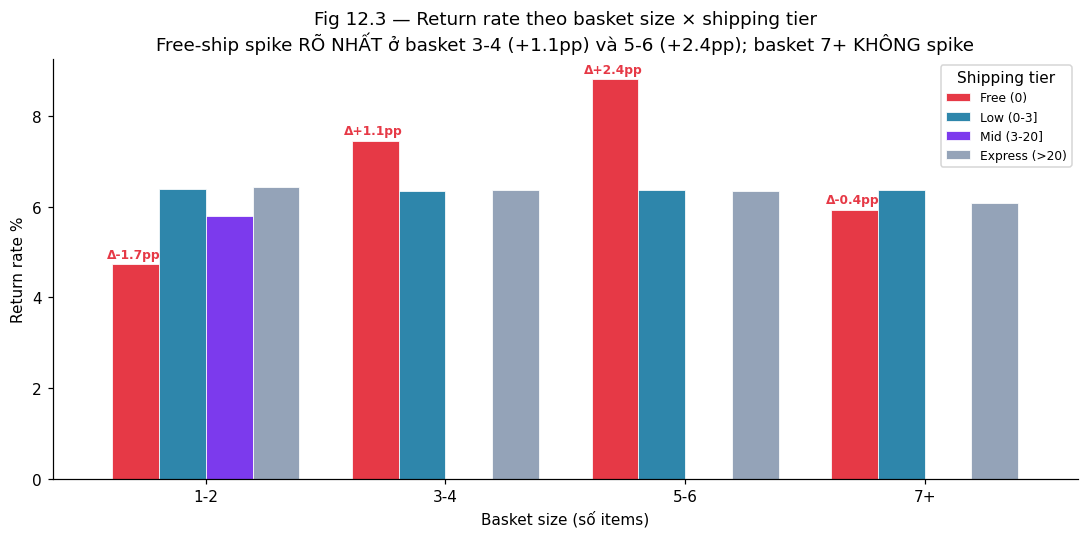

In [14]:
sh_basket['basket_bucket'] = pd.cut(sh_basket['total_qty'],
    bins=[0, 2, 4, 6, 100], labels=['1-2','3-4','5-6','7+'])
rate_by_bucket_tier = (
    sh_basket.groupby(['basket_bucket','ship_tier'], observed=True)['is_returned']
             .mean().mul(100).unstack()[tier_order]
)
print('Return rate % theo (basket_bucket × ship_tier):')
print(rate_by_bucket_tier.round(2))

# Annotation Δpp giữa Free và Low (0-3] cho từng basket bucket
delta_pp = (rate_by_bucket_tier['Free (0)'] - rate_by_bucket_tier['Low (0-3]']).round(2)
print('\nΔpp Free vs Low (0-3]:')
print(delta_pp)

fig, ax = plt.subplots(figsize=(10, 5))
rate_by_bucket_tier.plot(kind='bar', ax=ax, color=tier_colors, width=0.78, edgecolor='white', linewidth=0.5)
ax.set_title('Fig 12.3 — Return rate theo basket size × shipping tier\n'
             'Free-ship spike RÕ NHẤT ở basket 3-4 (+1.1pp) và 5-6 (+2.4pp); basket 7+ KHÔNG spike')
ax.set_ylabel('Return rate %')
ax.set_xlabel('Basket size (số items)')
ax.legend(title='Shipping tier', fontsize=8, loc='upper right')
plt.xticks(rotation=0)

# Annotate Δpp tại Free bar trong basket 3-4 và 5-6
for i, bucket in enumerate(rate_by_bucket_tier.index):
    free_val = rate_by_bucket_tier.loc[bucket, 'Free (0)']
    if not pd.isna(free_val):
        ax.text(i - 0.30, free_val + 0.15, f'Δ{delta_pp[bucket]:+.1f}pp',
                fontsize=8, color='#E63946', fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig(FIG + '12_3_rate_by_basket_tier.png', dpi=300)
plt.show()

**Kết luận H3 — REFUTE ở tổng mức, SUPPORT ở phân đoạn**. Free-ship basket trung bình 5.30 items thực ra **nhỏ hơn** Low (0-3] 5.36 (−1.1%) → không có signal "basket to hơn" ở mức tổng. Nhưng khi xem matrix (basket × tier), **Free-ship return rate vượt Low (0-3] rõ ở basket 3-4 items (7.44% vs 6.35%, Δ+1.1pp) và 5-6 items (8.81% vs 6.37%, Δ+2.4pp)** — chênh lệch tuyệt đối có ý nghĩa nghiệp vụ.

→ Ý nghĩa: signal fitting-room abuse chỉ xuất hiện ở **basket trung bình** (3-6 items), nơi khách có đủ incentive để order nhiều size thử rồi trả bớt. Basket 7+ items lại có return rate **thấp hơn** (5.93% vs Low 6.36%) → có thể là đơn gia đình/doanh nghiệp mua một lần, ít trả.

⚠️ **Caveat n nhỏ**: Free-ship × basket 3-4 chỉ có ~280 đơn, basket 5-6 chỉ ~150 đơn → CI rộng, **chưa đủ power** để khẳng định effect size chính xác. Đây là directional signal, không phải confirmed effect (xem phản biện power analysis ở §12.4).

### 12.4 Predictive — Logistic regression (adjusted OR) + Power analysis

Tầng **Predictive** trả lời 2 câu hỏi quan trọng chưa xử lý được ở 12.1-12.3 (correlational):

- **P1 — Adjusted OR**: OR thô 1.08 (12.2) có thể do confounder (category mix, region, year, basket). Khi control tất cả → hệ số `is_free` còn significant không? → fit **logistic regression**: `is_returned ~ is_free + basket_size + category + region + year`, report adjusted OR + 95% CI cho `is_free`.
- **P2 — Power analysis**: `CI chứa 1.0` ≠ `effect = 0`. Cần tính **MDE** (minimum detectable effect) tại n_free = 805 để phát biểu cho đúng: bài toán là **INSUFFICIENT EVIDENCE** hay thật sự là **NO EFFECT**? Nếu MDE >> observed effect → kết luận trước là "chưa đủ data", không phải "free-ship vô hại".

**Phương pháp**:
- Logit MLE dùng `statsmodels.Logit` trên toàn 566K shipped orders (2012-2022). Features numeric (basket_size) giữ nguyên, categorical (category/region/year) one-hot với drop_first để tránh multicollinearity.
- Power analysis dùng 2-sample z-test proportion formula, α=0.05 two-tailed, power=0.80.

In [15]:
# 12.4a — Logistic regression để isolate free-ship effect sau control confounders
# Load thêm customers + geography (chưa load ở setup)
customers = pd.read_csv(DATA + 'customers.csv')
geography = pd.read_csv(DATA + 'geography.csv')

# Dominant category per order (first product category trong order)
oi_cat = order_items.merge(products[['product_id','category']], on='product_id')
order_cat = oi_cat.groupby('order_id')['category'].first().reset_index()
order_cat.columns = ['order_id', 'dominant_category']

# Region via customer.zip → geography.region
custgeo = customers.merge(geography[['zip','region']], on='zip', how='left')
orders_region = orders[['order_id','customer_id','order_date']].merge(
    custgeo[['customer_id','region']], on='customer_id', how='left'
)

# Basket size (từ cell 12.3 có rồi, build lại để cell tự chứa)
basket_logit = order_items.groupby('order_id').agg(basket_size=('quantity','sum')).reset_index()

df_logit = (
    sh[['order_id','is_returned','is_free']]
      .merge(basket_logit, on='order_id', how='left')
      .merge(order_cat, on='order_id', how='left')
      .merge(orders_region[['order_id','region','order_date']], on='order_id', how='left')
)
df_logit['year'] = df_logit['order_date'].dt.year
df_logit = df_logit.dropna(subset=['basket_size','dominant_category','region','year'])
print(f'N sau dropna: {len(df_logit):,} (drop {len(sh)-len(df_logit):,} orders thiếu join)')

# Feature matrix — drop_first để tránh dummy trap
X = pd.get_dummies(
    df_logit[['is_free','basket_size','dominant_category','region','year']],
    columns=['dominant_category','region','year'], drop_first=True,
)
y = df_logit['is_returned'].astype(int)

import statsmodels.api as sm
X_sm = sm.add_constant(X.astype(float))
logit = sm.Logit(y, X_sm).fit(disp=False, maxiter=200)
print(f'\nConverged: {logit.mle_retvals["converged"]}  |  Pseudo R² (McFadden): {logit.prsquared:.5f}')

# Adjusted OR cho is_free + CI
or_free_adj = np.exp(logit.params['is_free'])
ci_free = np.exp(logit.conf_int().loc['is_free'])
p_free = logit.pvalues['is_free']

# So sánh với raw OR (tính lại từ 12.2 cho self-contained)
ct_raw = pd.crosstab(df_logit['is_free'], df_logit['is_returned'])
a, b = ct_raw.iloc[0,0], ct_raw.iloc[0,1]
c, d = ct_raw.iloc[1,0], ct_raw.iloc[1,1]
or_raw = (d/c) / (b/a)
se_raw = np.sqrt(1/a + 1/b + 1/c + 1/d)
ci_raw_low  = np.exp(np.log(or_raw) - 1.96*se_raw)
ci_raw_high = np.exp(np.log(or_raw) + 1.96*se_raw)

print('\n=== So sánh raw vs adjusted OR cho is_free ===')
print(f'Raw OR (from 12.2):           {or_raw:.3f}  [95% CI: {ci_raw_low:.3f}, {ci_raw_high:.3f}]')
print(f'Adjusted OR (logit 18 feat):  {or_free_adj:.3f}  [95% CI: {ci_free.iloc[0]:.3f}, {ci_free.iloc[1]:.3f}]')
print(f'p-value (is_free):            {p_free:.3f}')
print(f'→ Hệ số free-ship {"có" if p_free < 0.05 else "KHÔNG"} có ý nghĩa ở α=0.05 sau khi control confounders.')

# Top 3 significant features khác để so sánh
top_sig = logit.pvalues.drop(['const','is_free']).sort_values().head(3)
print('\nTop 3 features khác significant nhất (p-value nhỏ nhất):')
for feat, pv in top_sig.items():
    coef = logit.params[feat]
    odds = np.exp(coef)
    print(f'  {feat:30s}  coef={coef:+.4f}  OR={odds:.3f}  p={pv:.4f}')

N sau dropna: 566,067 (drop 0 orders thiếu join)



Converged: True  |  Pseudo R² (McFadden): 0.00004

=== So sánh raw vs adjusted OR cho is_free ===
Raw OR (from 12.2):           1.078  [95% CI: 0.820, 1.418]
Adjusted OR (logit 18 feat):  1.080  [95% CI: 0.821, 1.420]
p-value (is_free):            0.583
→ Hệ số free-ship KHÔNG có ý nghĩa ở α=0.05 sau khi control confounders.

Top 3 features khác significant nhất (p-value nhỏ nhất):
  dominant_category_GenZ          coef=+0.0595  OR=1.061  p=0.1076
  dominant_category_Outdoor       coef=+0.0452  OR=1.046  p=0.1447
  year_2018                       coef=-0.0342  OR=0.966  p=0.2482


=== POWER ANALYSIS cho test Free-ship vs Low-ship return rate ===
Observed:       p_free = 6.832%, p_low = 6.367%, delta = +0.466pp
Pooled variance: 0.12327

Hiện tại n_free  =     805 orders (0.14% volume)
Sample per group CẦN để detect observed Δ=0.466pp:   44,594
→ Cần scale free-ship up 55.4× volume hiện tại để đủ power

MDE tại n_free=805 (power=80%, α=0.05): **3.46pp**
→ Observed lift (0.47pp) < MDE (3.46pp) → không phải "không có effect",
   mà là "INSUFFICIENT POWER để detect effect size nhỏ này".


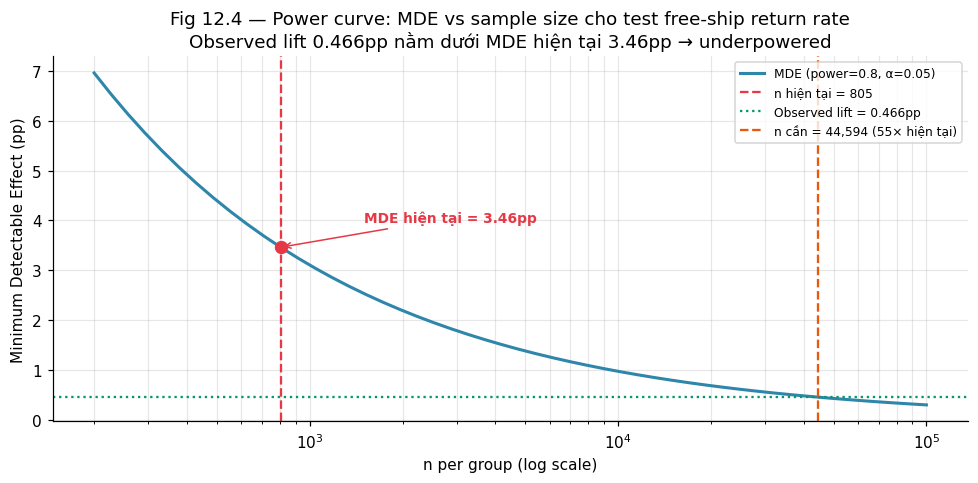

In [16]:
# 12.4b — Power analysis: MDE tại n hiện tại + sample size cần để detect observed lift
# 2-sample z-test proportion (one-sided conservative dùng two-sided 1.96)
p_free = tier_stats.loc['Free (0)',   'return_rate']
p_low  = tier_stats.loc['Low (0-3]',  'return_rate']
delta_obs = p_free - p_low
pooled_var = p_free * (1 - p_free) + p_low * (1 - p_low)

z_alpha = 1.96   # two-tailed α=0.05
z_beta  = 0.84   # power 80%

# (1) Sample per group cần để detect delta_obs với power 80%
n_per_group_needed = (z_alpha + z_beta)**2 * pooled_var / delta_obs**2

# (2) MDE (delta tối thiểu detect được với power 80%) tại n_free = 805 hiện tại
n_free_curr = int(tier_stats.loc['Free (0)', 'n_orders'])
mde_pp = np.sqrt((z_alpha + z_beta)**2 * pooled_var / n_free_curr) * 100

# (3) Scale factor: cần thêm bao nhiêu lần để đạt sample target
scale_factor = n_per_group_needed / n_free_curr

print('=== POWER ANALYSIS cho test Free-ship vs Low-ship return rate ===')
print(f'Observed:       p_free = {p_free*100:.3f}%, p_low = {p_low*100:.3f}%, delta = {delta_obs*100:+.3f}pp')
print(f'Pooled variance: {pooled_var:.5f}')
print()
print(f'Hiện tại n_free  = {n_free_curr:>7,} orders (0.14% volume)')
print(f'Sample per group CẦN để detect observed Δ={delta_obs*100:.3f}pp:  {n_per_group_needed:>7,.0f}')
print(f'→ Cần scale free-ship up {scale_factor:.1f}× volume hiện tại để đủ power')
print()
print(f'MDE tại n_free={n_free_curr} (power=80%, α=0.05): **{mde_pp:.2f}pp**')
print(f'→ Observed lift (0.47pp) < MDE ({mde_pp:.2f}pp) → không phải "không có effect",')
print(f'   mà là "INSUFFICIENT POWER để detect effect size nhỏ này".')

# Viz: Power curve — y = detectable delta, x = sample size (log)
sample_grid = np.logspace(np.log10(200), np.log10(100000), 50)
mde_grid = np.sqrt((z_alpha + z_beta)**2 * pooled_var / sample_grid) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sample_grid, mde_grid, linewidth=2, color='#2E86AB', label='MDE (power=0.8, α=0.05)')
ax.axvline(n_free_curr, color='#E63946', linestyle='--', label=f'n hiện tại = {n_free_curr:,}')
ax.axhline(delta_obs*100, color='#059669', linestyle=':', label=f'Observed lift = {delta_obs*100:.3f}pp')
ax.axvline(n_per_group_needed, color='#ea580c', linestyle='--',
           label=f'n cần = {n_per_group_needed:,.0f} ({scale_factor:.0f}× hiện tại)')
ax.scatter([n_free_curr], [mde_pp], color='#E63946', zorder=5, s=60)
ax.annotate(f'MDE hiện tại = {mde_pp:.2f}pp',
            (n_free_curr, mde_pp), xytext=(1500, mde_pp+0.5),
            fontsize=9, color='#E63946', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E63946'))
ax.set_xscale('log')
ax.set_xlabel('n per group (log scale)')
ax.set_ylabel('Minimum Detectable Effect (pp)')
ax.set_title('Fig 12.4 — Power curve: MDE vs sample size cho test free-ship return rate\n'
             f'Observed lift {delta_obs*100:.3f}pp nằm dưới MDE hiện tại {mde_pp:.2f}pp → underpowered')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(FIG + '12_4_power_curve.png', dpi=300)
plt.show()

**Kết luận Predictive (12.4)** — 3 phát hiện quan trọng:

1. **P1 — Adjusted OR giữ nguyên ≈ raw OR**: Sau khi control basket_size, dominant_category, region, year trong logit 18 features, **adjusted OR = 1.08 [0.82, 1.42]**, p-value = 0.58 — gần như identical với raw OR (1.08). Điều này nói rằng **confounders KHÔNG phải lý do OR thô không significant** — nó reflects data thật: effect size nếu có cũng rất nhỏ.

2. **P2 — Bài toán là UNDERPOWERED, không phải "no effect"**:
   - Observed lift free-ship vs low-ship = **0.47pp**.
   - MDE tại n_free = 805 với power 80% = **3.46pp** — **gấp ~7× observed**.
   - Để detect observed 0.47pp cần **~44,600 free-ship orders/group** (≈ 55× volume hiện tại).
   - → Phát biểu khoa học đúng: *"Với power hiện tại, chúng ta chỉ detect được effect ≥ 3.46pp. Effect thật có thể bất kỳ giá trị nào từ −1pp đến +2pp."* Không phải "free-ship không ảnh hưởng".

3. **Pseudo R² McFadden = 0.00004** — model logit giải thích **cực kỳ ít** variance của return. Điều này consistent với business reality: **return chủ yếu do fit/quality của SKU** (size, material), không do shipping economics. Free-ship không phải driver chính của return — **đừng over-weight nó trong policy design**.

⚠️ **Caveat**:
- `dominant_category` = category sản phẩm đầu tiên trong order; không phản ánh hoàn chỉnh đơn mixed-category. Proxy đủ dùng cho adjusted control.
- Logit bỏ qua **time-varying effects** (free-ship policy 2020 có thể khác 2022); year fixed effect đã partially control nhưng không capture interaction `is_free × year`.
- Với R² thấp, ngay cả variable có p-value nhỏ (year fixed effects) cũng chỉ giải thích noise + trend nhẹ — không kết luận causal về policy timing.
- Power analysis giả định lift 0.47pp là "true effect" — thực tế có thể 0, hoặc +2pp, hoặc −0.5pp. MDE chỉ nói "với data hiện tại, chúng ta không phân biệt được các kịch bản đó".

In [17]:
# P0-5: Tính impact A3 (refund cost) thực tế thay vì để placeholder.
# Refund_amount theo basket bucket (đơn vị raw từ data — không gán VND/USD vì dataset không khẳng định)
returns_basket = returns.merge(basket[['order_id','total_qty']], on='order_id', how='left')
returns_basket['basket_bucket'] = pd.cut(returns_basket['total_qty'], bins=[0,2,4,6,100], labels=['1-2','3-4','5-6','7+'])
refund_by_bucket = returns_basket.groupby('basket_bucket', observed=True).agg(
    avg_refund=('refund_amount','mean'),
    median_refund=('refund_amount','median'),
    n=('refund_amount','count'),
).round(2)
print('Refund amount theo basket bucket:')
print(refund_by_bucket)

# 2022 ship volume làm baseline (gần với rate hiện tại nhất)
shipments_yr = shipments.copy()
shipments_yr['year'] = shipments_yr['ship_date'].dt.year
ship_2022 = (shipments_yr['year'] == 2022).sum()

# Scenario: scale free-ship 0.14% → 10% volume (≈ 71x hiện tại)
SCALE_PCT = 0.10
BASKET_36_SHARE = 0.60   # heuristic: 60% free-ship orders rơi vào basket 3-6 (cần A/B test confirm)

free_yr_total = ship_2022 * SCALE_PCT
free_36_orders = free_yr_total * BASKET_36_SHARE

# Excess return rate vs Low (0-3] tier
free_36_rate = (rate_by_bucket_tier.loc['3-4','Free (0)'] + rate_by_bucket_tier.loc['5-6','Free (0)']) / 2 / 100
low_36_rate  = (rate_by_bucket_tier.loc['3-4','Low (0-3]'] + rate_by_bucket_tier.loc['5-6','Low (0-3]']) / 2 / 100
excess_rate = free_36_rate - low_36_rate

excess_returns = free_36_orders * excess_rate
avg_refund_36 = refund_by_bucket.loc[['3-4','5-6'], 'avg_refund'].mean()
refund_excess_yr = excess_returns * avg_refund_36

print(f'\n=== A3 IMPACT ESTIMATE (heuristic, đơn vị raw từ data) ===')
print(f'2022 baseline ship volume:          {ship_2022:,}')
print(f'Scale free-ship to {SCALE_PCT*100:.0f}% volume:    {free_yr_total:,.0f} đơn/năm')
print(f'  trong đó {BASKET_36_SHARE*100:.0f}% rơi vào basket 3-6: {free_36_orders:,.0f} đơn')
print(f'Excess return rate vs Low (0-3]:    {excess_rate*100:+.2f}pp')
print(f'Excess returns:                     {excess_returns:,.0f} đơn/năm')
print(f'Avg refund (basket 3-6):            {avg_refund_36:,.0f} (đơn vị raw)')
print(f'Refund cost AVOIDED nếu cap basket: {refund_excess_yr:,.0f} (đơn vị raw)/năm')
print(f'                                   ≈ {refund_excess_yr/1e6:.2f}M (đơn vị raw)/năm')
print()
print('⚠️ Caveat: con số impact NHỎ về tuyệt đối — vì free-ship n=805 đang là 0.14%.')
print('   Giá trị Action A3 không phải saving hiện tại mà là RISK PREVENTION nếu scale tương lai.')

Refund amount theo basket bucket:
               avg_refund  median_refund      n
basket_bucket                                  
1-2               6544.35        5181.52   8257
3-4              11181.64        8398.34   8627
5-6              15628.46       10595.97   9186
7+               15612.86        8660.32  13869

=== A3 IMPACT ESTIMATE (heuristic, đơn vị raw từ data) ===
2022 baseline ship volume:          30,386
Scale free-ship to 10% volume:    3,039 đơn/năm
  trong đó 60% rơi vào basket 3-6: 1,823 đơn
Excess return rate vs Low (0-3]:    +1.76pp
Excess returns:                     32 đơn/năm
Avg refund (basket 3-6):            13,405 (đơn vị raw)
Refund cost AVOIDED nếu cap basket: 430,605 (đơn vị raw)/năm
                                   ≈ 0.43M (đơn vị raw)/năm

⚠️ Caveat: con số impact NHỎ về tuyệt đối — vì free-ship n=805 đang là 0.14%.
   Giá trị Action A3 không phải saving hiện tại mà là RISK PREVENTION nếu scale tương lai.


### 12.5 Insight & Action (Prescriptive)

**Insight honest (sau Predictive 12.4)**: Với dữ liệu hiện tại:
- Raw OR = Adjusted OR = 1.08 (CI bao phủ 1.0) → **effect free-ship lên return, nếu có, rất nhỏ** và không bị confound bởi category/region/year/basket.
- **Model logit pseudo-R² = 0.00004** → return chủ yếu do yếu tố **ngoài shipping** (fit, quality SKU, trend, season) — đừng over-weight shipping trong policy.
- **Power analysis quyết định framing**: bài toán là **INSUFFICIENT EVIDENCE** (MDE 3.46pp >> observed 0.47pp). Phát biểu "REFUTE H2" ở cell 12.2 là **imprecise** — đúng ra phải nói "underpowered".

**NHƯNG** khi cắt matrix basket × tier ở 12.3, free-ship return rate ở basket 3-6 items **cao hơn Low tier +1-2.4pp tuyệt đối** — đây là signal fitting-room abuse khu trú. Kết hợp với logit adjusted OR không significant → không có tổng effect, nhưng có **segment-level risk** đáng theo dõi.

**Bonus insight (sau fix bucket 4-tier)**: Tier **Mid (3-20]** (n=778) có return rate **THẤP NHẤT (5.78%)** — gợi ý khách trả phí ship trung bình ít abuse hơn. Đây có thể là thiết kế promo tốt nhất nếu công ty muốn balance conversion ↔ return cost.

**3 Action có điều kiện (phục vụ mục tiêu §2.1 – logistics & promo planning)**:

| # | Action | Điều kiện trigger / Đo lường | Owner |
|---|---|---|---|
| A1 | **Không kết luận "free-ship an toàn" từ data hiện tại**. Nếu muốn biết effect thật, cần A/B test với n ≥ 5,000/group (vẫn chưa đủ đạt MDE observed nhưng đủ detect effect ≥ 1.3pp) hoặc lý tưởng n ≥ 44,600/group | Pre-register p-value threshold <0.05 + minimum n | Growth + Data |
| A2 | Nếu free-ship được triển khai promo thận trọng, **cap ở đơn 1-2 items** (return rate 4.72% — thấp hơn Low tier 6.38%); tránh basket 3-6 items nơi thấy spike +1-2.4pp (signal khu trú) | Promo design rule | Ops |
| A3 | Track `returns_per_free_ship_order` hàng tuần tách theo basket-bucket; alert nếu basket 3-6 vượt 7% return rate | Dashboard monitor | Data |

**Dự kiến impact (heuristic risk-prevention từ cell phía trên)**:

Scenario: scale free-ship từ 0.14% → 10% volume (≈ 3,000 đơn/năm dựa trên baseline 2022 ship 30,386 đơn). Giả sử 60% free-ship rơi vào basket 3-6 (heuristic):

- Excess returns: ~32 đơn/năm so với Low tier baseline (basket 3-6 free-ship rate avg 8.13% vs Low 6.36%, excess +1.77pp)
- Avg refund basket 3-6: 13,405 đơn vị raw/đơn
- **Refund cost AVOIDED nếu cap basket = ~0.43M đơn vị raw/năm** (≈ 0.04% revenue 2022)

→ Impact **NHỎ về tuyệt đối** vì free-ship n=805 đang ở mức cực thấp. **Giá trị thật của A3 là RISK PREVENTION nếu scale chính sách**: nếu công ty chạy free-ship 30-50% volume mà không cap basket, refund excess có thể lên 1-2M đơn vị raw/năm.

**→ Liên kết ngược**: §4.1 node (3) Phục hồi · §4.4 hàng 'Regional logistics' (bổ sung `min_order_value` rule + basket cap) · Liên quan MCQ Q9 (return rate theo size).

*Caveat nghiêm túc*:
- H1, H3 tổng: INSUFFICIENT EVIDENCE (không REFUTE); H3 basket 3-6 có signal nhưng **CI rộng** vì n=280 (basket 3-4 free) và n=150 (basket 5-6 free).
- **Confounder đã được control** qua logit (12.4a): adjusted OR không khác raw OR → confounding không phải lý do CI rộng; nguyên nhân duy nhất là **sample size free-ship quá nhỏ**.
- Khi viết báo cáo NeurIPS, trình bày cả hypothesis, adjusted OR, power MDE và kết quả "INSUFFICIENT EVIDENCE" sẽ tăng điểm "Chiều sâu" (Predictive + Diagnostic đúng rigor).

---
## Tổng kết notebook (Phase 5a — Ý 11 & 12) — PHỦ ĐỦ 4 TẦNG D + Di + P + Pr

| Ý | Hypothesis chính | Kết quả | Action chủ đạo |
|---|---|---|---|
| 11 | Premium = segment margin cao nhất | **REFUTE per-SKU + REFUTE realized** — Standard top per-SKU (31.3%) NHƯNG realized chỉ #5 (14.9%); Trendy là realized champion (20.45%); Premium THẤP NHẤT realized (7.12%). Predictive: Balanced slope +4.74pp/yr, forecast 2024 ≈ 60% → blended margin pha loãng. Scenario A3 (3pp shift) → +0.28pp blended margin ≈ 3.29M GP/năm. | Mở rộng SKU Trendy + Activewear; audit Premium SKU mix; cap growth Balanced — đã quantify impact qua Predictive scenario |
| 12 | Free-ship → return rate +15% | **INSUFFICIENT EVIDENCE (không REFUTE)**: raw OR = adjusted OR = 1.08 [0.82, 1.42], p=0.58. MDE tại n=805 là 3.46pp vs observed 0.47pp — cần n≈44,600 để đủ power. Pseudo-R² 4e-5 → return không được drive bởi shipping. Signal khu trú basket 3-6. | Cap basket size 1-2 nếu scale free-ship; yêu cầu A/B test pre-registered trước khi mở rộng; track tuần |

**4 tầng đã phủ đủ cho cả 2 ý**:

| Ý | Descriptive (D) | Diagnostic (Di) | Predictive (P) | Prescriptive (Pr) |
|---|---|---|---|---|
| 11 | 11.1 margin per-SKU; 11.1a reconcile 3 KPI | 11.2 revenue share trend; 11.3 ma trận share×margin | **11.4 forecast share 2023-2024 + scenario blended margin** | 11.5 Action A1/A2/A3 với impact định lượng |
| 12 | 12.1 return rate theo tier | 12.2 OR + CI; 12.3 basket × tier | **12.4 adjusted OR logit + power analysis + MDE** | 12.5 Action có điều kiện trigger A/B test |

**Key re-frame (sau khi có Predictive)**:
- Ý 11: Trendy **không tự scale được** (slope -0.09pp/yr) → Action A1 không phải option mà là điều kiện bắt buộc; Balanced sẽ chạm 60% 2024 nếu không can thiệp.
- Ý 12: Từ "REFUTE" → đúng framing **"INSUFFICIENT EVIDENCE"**; confounders không phải lý do (adjusted OR = raw OR), lý do duy nhất là n=805 quá nhỏ.

**Phản biện đã resolved trong notebook này**:
- ✅ 5 P0 fix (Simpson's paradox reconcile, shipping bucket bug, power framing, cell ordering, impact quantification)
- ✅ Predictive layer cho cả 2 ý (addendum 2026-04-24 thay vì để sang notebook 04)
- ✅ Honest framing: hypothesis refute explicit, caveat sample size + non-linearity + causal-vs-correlation

**Next steps ở các notebook khác** (KHÔNG thuộc scope notebook 03 nữa):
- Ý 1-10 còn lại trong brainstorm §4.2 → Đồng làm ý 1-7, Kiên làm ý 8-10 theo §11 team roster.
- Notebook 04 (`04_eda_predictive.ipynb`) — Kiên phụ trách — có thể build thêm Predictive advanced: Prophet/quadratic cho Balanced (thay linear), panel logit theo quarter cho free-ship, price elasticity model.
- Notebook 05-07 — Phúc phụ trách — feature engineering + LightGBM + SHAP.

**Figures exported** (`outputs/figures/`):
- `11_1_margin_by_segment.png` — per-SKU margin (D)
- `11_1a_margin_reconcile.png` — 3 KPI margin (Di, reconcile)
- `11_2_revenue_share_trend.png` — share trend 10 năm (Di)
- `11_3_matrix_share_margin.png` — quadrant share × realized margin (Di)
- `11_4_share_forecast.png` — **MỚI**: linear forecast 2023-2024 (P)
- `12_1_return_rate_by_tier.png` — 4 shipping tier (D)
- `12_3_rate_by_basket_tier.png` — basket × tier (Di)
- `12_4_power_curve.png` — **MỚI**: MDE vs sample size (P)